<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/Event_Studies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar de datos

In [1]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re

BASE = "https://www.latinobarometro.org"
INDEX = f"{BASE}/agregados"

headers = {
    "User-Agent": "Mozilla/5.0"
}

# =========================
# 1. obtener páginas de cada ola
# =========================

html = requests.get(INDEX, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

wave_pages = []

for a in soup.find_all("a", href=True):

    href = a["href"]

    # links tipo /latinobarometro-2023
    if re.search(r"latinobarometro-\d{4}$", href):

        full = urljoin(BASE, href)
        wave_pages.append(full)

wave_pages = sorted(set(wave_pages))

print("Olas encontradas:")
for w in wave_pages:
    print(w)

# =========================
# 2. entrar a cada ola y buscar ZIP de Stata
# =========================

stata_links = []

for page in wave_pages:

    print(f"\nRevisando {page}")

    try:
        html = requests.get(page, headers=headers, timeout=20).text
        soup = BeautifulSoup(html, "html.parser")

        for a in soup.find_all("a", href=True):

            href = a["href"]
            text = a.get_text(" ", strip=True).lower()

            full = urljoin(page, href)

            # queremos ZIPs relacionados con Stata
            if (
                ".zip" in href.lower()
                and (
                    "stata" in href.lower()
                    or "dta" in href.lower()
                    or "stata" in text
                )
            ):
                stata_links.append(full)

    except Exception as e:
        print("Error:", e)

# limpiar duplicados
stata_links = sorted(set(stata_links))

print("\nZIPs Stata encontrados:\n")

for l in stata_links:
    print(l)

Olas encontradas:
https://www.latinobarometro.org/latinobarometro-1995
https://www.latinobarometro.org/latinobarometro-1996
https://www.latinobarometro.org/latinobarometro-1997
https://www.latinobarometro.org/latinobarometro-1998
https://www.latinobarometro.org/latinobarometro-2000
https://www.latinobarometro.org/latinobarometro-2001
https://www.latinobarometro.org/latinobarometro-2002
https://www.latinobarometro.org/latinobarometro-2003
https://www.latinobarometro.org/latinobarometro-2004
https://www.latinobarometro.org/latinobarometro-2005
https://www.latinobarometro.org/latinobarometro-2006
https://www.latinobarometro.org/latinobarometro-2007
https://www.latinobarometro.org/latinobarometro-2008
https://www.latinobarometro.org/latinobarometro-2009
https://www.latinobarometro.org/latinobarometro-2010
https://www.latinobarometro.org/latinobarometro-2011
https://www.latinobarometro.org/latinobarometro-2013
https://www.latinobarometro.org/latinobarometro-2015
https://www.latinobarometro.

In [2]:
import requests

import shutil
import os

# borrar carpeta rota
shutil.rmtree("latinobarometro", ignore_errors=True)

# recrear
os.makedirs("latinobarometro", exist_ok=True)

for link in stata_links:

    filename = link.split("/")[-1]
    filepath = os.path.join("latinobarometro", filename)

    print("Descargando:", filename)

    r = requests.get(link)

    with open(filepath, "wb") as f:
        f.write(r.content)

Descargando: latinobarometro-1995-dta.zip
Descargando: latinobarometro-1996-dta.zip
Descargando: latinobarometro-1997-dta.zip
Descargando: latinobarometro-1998-dta.zip
Descargando: latinobarometro-2000-dta.zip
Descargando: latinobarometro-2001-dta.zip
Descargando: latinobarometro-2002-dta.zip
Descargando: latinobarometro-2003-dta.zip
Descargando: latinobarometro-2004-dta.zip
Descargando: latinobarometro-2005-dta.zip
Descargando: latinobarometro-2006-dta.zip
Descargando: latinobarometro-2007-dta.zip
Descargando: latinobarometro-2008-dta.zip
Descargando: latinobarometro-2009-dta.zip
Descargando: latinobarometro-2010-dta.zip
Descargando: latinobarometro-2011-dta.zip
Descargando: latinobarometro-2013-dta.zip
Descargando: latinobarometro-2015-dta.zip
Descargando: latinobarometro2016-dta.zip
Descargando: latinobarometro2017-dta.zip
Descargando: latinobarometro-2018-eng-stata-v20190303.zip
Descargando: latinobarometro-2018-esp-dta-v20190303.zip
Descargando: latinobarometro-2020-eng-stata-v1-0

In [3]:
!mkdir -p latinobarometro/unzipped

!find latinobarometro -name "*.zip" -exec unzip -o {} -d latinobarometro/unzipped \;

Archive:  latinobarometro/latinobarometro2016-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro2016Eng_v20170205.dta  
  inflating: latinobarometro/unzipped/Latinobarometro2016EngQuestionnaire.docx  
  inflating: latinobarometro/unzipped/Latinobarometro2016Esp_v20170205.dta  
  inflating: latinobarometro/unzipped/Latinobarometro2016EspCuestionario.docx  
Archive:  latinobarometro/latinobarometro-2020-esp-stata-v1-0.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2020_Esp_Stata_v1_0.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_2020_Eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2020_Esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2020_Eng_Stata_v1_0.dta  
Archive:  latinobarometro/latinobarometro-2007-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2007_eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2007_esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2007_datos_esp_v2014

In [34]:
# =========================
# mapeo armonizado
# =========================

varmap = {

    # ---------------------------------
    # satisfacción con la vida
    # ---------------------------------

    "life_satisfaction": {

        1997: "nsp10",
        2000: "P8ST",
        2001: "p41st",
        2002: "p1wvs",
        2003: "p19st",
        2004: "p1st",
        2005: "p1st",
        2006: "p1st_a",
        2007: "p1st",
        2008: "p27st",
        2009: "p1st",
        2010: "P1ST",
        2011: "P1ST",
        2013: "P1ST",
        2015: "P1ST",
        2016: "P1ST",
        2017: "P1ST",
        2018: "P1STC",
        2020: "p1st",
        2023: "P1ST",
        2024: "P1ST"
    },


    # ---------------------------------
    # situación económica actual del país
    # ---------------------------------

    "econ_country": {

        1995: "p1",
        1996: "p1",
        1997: "sp1",
        1998: "sp1",
        2000: "P1ST",
        2001: "p1st",
        2002: "p2sta",
        2003: "p1st",
        2004: "p2st",
        2005: "p2st",
        2006: "p2st",
        2007: "p100st",
        2008: "p4st",
        2009: "p3st_a",
        2010: "P3ST_A",
        2011: "P3ST_A",
        2013: "P3STGBS",
        2015: "P3STGBS",
        2016: "P4STGBS",
        2017: "P4STGBSC",
        2018: "P6STGBSC",
        2020: "p4stgbs",
        2023: "P5STGBS",
        2024: "P6STGBS"
    },

    # ---------------------------------
    # confianza interpersonal
    # ---------------------------------

    "trust_people": {

        1996: "p12",
        1997: "sp21",
        1998: "sp20",
        2000: "P17ST",
        2001: "p42st",
        2002: "p29st",
        2003: "p20st",
        2004: "p43st",
        2005: "p14st",
        2006: "p45st",
        2007: "p23st",
        2008: "p21wvsst",
        2009: "p58st",
        2010: "P55ST",
        2011: "P25ST",
        2013: "P29STGBS",
        2015: "P15STGBS",
        2016: "P12STGBS",
        2017: "P13STGBS",
        2018: "P11STGBS",
        2020: "p9stgbs",
        2023: "P9STGBS",
        2024: "P10STGBS"
    },

    # ---------------------------------
    # ciudad
    # ---------------------------------

    "city": {
        1997: "ciudad",
        2000: "ciudad",
        2001: "ciudad",
        2003: "ciudad",
        2004: "Ciudad",
        2005: "ciudad",
        2006: "ciudad",
        2007: "ciudad",
        2008: "ciudad",
        2009: "ciudad",
        2010: "ciudad",
        2011: "ciudad",
        2013: "ciudad",
        2015: "ciudad",
        2016: "ciudad",
        2017: "ciudad",
        2018: "CIUDAD",
        2020: "ciudad",
        2023: "ciudad",
        2024: "CIUDAD"
    },

    # ---------------------------------
    # interés en política
    # ---------------------------------

    "interest_politics": {

        1995: "p62",
        1996: "p64",
        1997: "sp41",
        1998: "sp36",
        2000: "P63ST",
        2001: "p56st",
        2003: "p61st",
        2004: "p29st",
        2005: "p37st",
        2007: "p59st",
        2009: "p32st",
        2010: "P23ST",
        2013: "P20STGBS",
        2020: "p46stgbs",
        2023: "P40STGBS",
        2024: "P36STGBS",

    },

    # ---------------------------------
    # sexo
    # ---------------------------------

    "sex": {

        1995: "s1",
        1996: "s1",
        1997: "s1",
        1998: "s1",
        2000: "S1",
        2001: "s1",
        2002: "s1",
        2003: "s1",
        2004: "s1",
        2005: "s6",
        2006: "s6",
        2007: "s10",
        2008: "s8",
        2009: "s5",
        2010: "S7",
        2011: "S16",
        2013: "S10",
        2015: "S12",
        2016: "sexo",
        2017: "sexo",
        2018: "SEXO",
        2020: "sexo",
        2023: "sexo",
        2024: "SEXO"
    },

    # ---------------------------------
    # edad
    # ---------------------------------

    "age": {

        1995: "s2",
        1996: "s2",
        1997: "s2",
        1998: "s2",
        2000: "S2",
        2001: "s2",
        2002: "s2",
        2003: "s2",
        2004: "s2",
        2005: "s7",
        2006: "s7",
        2007: "s11",
        2008: "s9",
        2009: "s6",
        2010: "S8",
        2011: "S17",
        2013: "S11",
        2015: "S13",
        2016: "edad",
        2017: "edad",
        2018: "EDAD",
        2020: "edad",
        2023: "edad",
        2024: "EDAD"
    },

    # ---------------------------------
    # estado civil
    # ---------------------------------

    "civil_status": {

        1995: "s6",
        1996: "s5",
        1997: "s5",
        1998: "s5",
        2000: "S4",
        2001: "s4",
        2002: "s4",
        2003: "s4",
        2004: "s4",
        2005: "s9",
        2006: "s9",
        2007: "s13",
        2008: "s3",
        2009: "s3",
        2010: "S5",
        2011: "S15",
        2013: "S9",
        2015: "S11",
        2016: "S5",
        2017: "S6",
        2018: "S23"
    },

    # ---------------------------------
    # izquierda-derecha
    # ---------------------------------

    "left_right": {

        1995: "p31",
        1996: "p38",
        1997: "sp56",
        1998: "sp52",
        2000: "P52ST",
        2001: "p54st",
        2002: "p64st",
        2003: "p60st",
        2004: "p87st",
        2005: "p34st",
        2006: "p47st",
        2007: "p67st",
        2008: "p56st",
        2009: "p69st",
        2010: "P60ST",
        2011: "P76ST",
        2013: "P41ST",
        2015: "P27ST",
        2016: "P17ST",
        2017: "P19STC",
        2018: "P22ST",
        2020: "p18st",
        2023: "P16ST",
        2024: "P16ST"
    },


    # ---------------------------------
    # país
    # ---------------------------------

    "country": {

        1995: "pais",
        1996: "pais",
        1997: "idenpa",
        1998: "idenpa",
        2000: "idenpa",
        2001: "idenpa",
        2002: "idenpa",
        2003: "idenpa",
        2004: "idenpa",
        2005: "idenpa",
        2006: "idenpa",
        2007: "idenpa",
        2008: "idenpa",
        2009: "idenpa",
        2010: "idenpa",
        2011: "idenpa",
        2013: "idenpa",
        2015: "idenpa",
        2016: "idenpa",
        2017: "idenpa",
        2018: "IDENPA",
        2020: "idenpa",
        2023: "idenpa",
        2024: "IDENPA"
    },

    # ---------------------------------
    # educación
    # ---------------------------------

"education": {

    1995: "s17",
    1996: "s14",
    1997: "s10",
    1998: "s11",
    2000: "S6",
    2001: "s6",
    2002: "s6",
    2003: "s6",
    2004: "s6",
    2005: "s11",
    2006: "s11",
    2007: "s15",
    2008: "s15",
    2009: "s12",
    2010: "S14",
    2011: "S21",
    2013: "S17",
    2015: "S19",
    2016: "S13",
    2017: "S14",
    2018: "S10",
    2020: "s16",
    2023: "S11",
    2024: "S11"
},

# ---------------------------------
# twitter
# ---------------------------------

"twitter": {

    2009: "S25_E",
    2010: "S27_E",
    2011: "S33ST_BE",
    2013: "P83TNCE",
    2015: "S10M_E",
    2016: "S15M_D",
    2017: "S16M_D",
    2018: "S12M.D",
    2020: "s19m_04",
    2023: "S14M_D",
    2024: "S14M.4"

},

# ---------------------------------
# Voto
# ---------------------------------
"vote": {

    1995: "p33",
    1996: "p40",
    1997: "sp58",
    1998: "sp53",
    2000: "P54ST",
    2001: "p55st",
    2002: "p45st",
    2003: "p54st",
    2004: "p30st",
    2005: "p48st",
    2006: "p38st",
    2007: "p64st",
    2008: "p61st",
    2009: "p35st",
    2010: "P29ST",
    2011: "P38ST",
    2013: "P22TGBSM",
    2015: "P23TGBSM",
    2016: "P15STGBS",
    2017: "P16STGBS",
    2018: "P21STGBS.A",
    2020: "P50STGBS_A",
    2023: "P43STGBS_A",
    2024: "P39STGBS.A"
},

# ---------------------------------
# Confianza en el Congreso
# ---------------------------------

"confianza_congreso": {
    1995: "p27i",
    1996: "p33i",
    1997: "sp63f",
    1998: "sp38f",
    2000: "P35ST_F",
    2001: "p61stf",
    2002: "p36std",
    2003: "p21stf",
    2004: "p34stf",
    2005: "p45sta",
    2006: "p24st_f",
    2007: "p24st_f",
    2008: "p28st_a",
    2009: "p26st_a",
    2010: "P20ST_A",
    2011: "P22ST_A",
    2013: "P26TGB_C",
    2015: "P16ST_F",
    2016: "P13STD",
    2017: "P14ST_D",
    2018: "P15STGBSC.D",
    2020: "p13st_d",
    2023: "P13ST_D",
    2024: "P14ST.D"
},

# ---------------------------------
# Confianza en el Gobierno
# ---------------------------------

"confianza_gobierno": {
    1995: "p27m",
    1996: "p33m",
    2002: "p34std",
    2003: "p23stg",
    2004: "p32std",
    2005: "p45stc",
    2006: "p32st_a",
    2007: "p24st_a",
    2008: "p31s_ta",
    2009: "p24st_a",
    2010: "P18ST_A",
    2011: "P20ST_A",
    2013: "P26TGB_B",
    2015: "P16ST_G",
    2016: "P13STE",
    2017: "P14ST_E",
    2018: "P15STGBSC.E",
    2020: "p13st_e",
    2023: "P13ST_E",
    2024: "P14ST.E"
},

# ---------------------------------
# Confianza en el Poder Judicial
# ---------------------------------

"confianza_judicial": {
    1995: "p27d",
    1996: "p33d",
    1997: "sp63c",
    1998: "sp38c",
    2000: "P35ST_C",
    2001: "p61stc",
    2002: "p34stc",
    2003: "p21ste",
    2004: "p34stb",
    2005: "p42std",
    2006: "p24st_a",
    2007: "p24st_d",
    2008: "p28st_b",
    2009: "p26st_b",
    2010: "P20ST_B",
    2011: "P22ST_B",
    2013: "P26TGB_E",
    2015: "P16ST_H",
    2016: "P13STF",
    2017: "P14ST_F",
    2018: "P15STGBSC.F",
    2020: "p13st_f",
    2023: "P13ST_F",
    2024: "P14ST.F"
},

# ---------------------------------
# Día
# ---------------------------------

"dia_real": {
    1997: "diareal",
    1998: "diareal",
    2000: "diareal",
    2001: "diareal",
    2002: "diareal",
    2003: "diareal",
    2004: "diareal",
    2005: "diareal",
    2006: "diareal",
    2007: "diareal",
    2008: "diareal",
    2009: "diareal",
    2010: "diareal",
    2011: "diareal",
    2013: "diareal",
    2015: "diareal",
    2016: "diareal",
    2017: "diareal",
    2018: "DIAREAL",
    2020: "diareal",
    2023: "diareal",
    2024: "DIAREAL",
},


# ---------------------------------
# Mes
# ---------------------------------

"mes_real": {
    1997: "mesreal",
    1998: "mesreal",
    2000: "mesreal",
    2001: "mesreal",
    2002: "mesreal",
    2003: "mesreal",
    2004: "mesreal",
    2005: "mesreal",
    2006: "mesreal",
    2007: "mesreal",
    2008: "mesreal",
    2009: "mesreal",
    2010: "mesreal",
    2011: "mesreal",
    2013: "mesreal",
    2015: "mesreal",
    2016: "mesreal",
    2017: "mesreal",
    2018: "MESREAL",
    2020: "mesreal",
    2023: "mesreal",
    2024: "MESREAL",
}


}

In [31]:
import re

# Buscar archivo 2024
file_2024 = [
    f for f in dta_files
    if "1995" in f.name
][0]

# Leer sólo las primeras filas
tmp = pd.read_stata(
    file_2024,
    convert_categoricals=False,
    iterator=True
)

df_2024 = tmp.read(5)

print("Archivo:", file_2024)
print("\nPrimeras 10 columnas:")
print(df_2024.columns[:20].tolist())

Archivo: latinobarometro/unzipped/Latinobarometro_1995_datos_esp_v2014_06_27.dta

Primeras 10 columnas:
['numero', 'pais', 'enc', 'region', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15a', 'p15b']


In [35]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path("latinobarometro/unzipped")

# =========================
# buscar archivos
# =========================

dta_files = sorted([
    f for f in BASE.rglob("*.dta")
    if "eng" not in f.name.lower()
])

# =========================
# detectar ola
# =========================

def detect_wave(path):

    m = re.search(r"(19|20)\d{2}", path.name)

    if m:
        return int(m.group())

    return np.nan

# =========================
# verificar SOLO faltantes
# =========================

for file in dta_files:

    try:

        wave = detect_wave(file)

        # leer pocas filas
        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        existing_cols = set(tmp.columns)

        missing = []

        # -------------------------
        # revisar varmap
        # -------------------------

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var not in existing_cols:

                missing.append(
                    f"{new_name} -> {old_var}"
                )

        # -------------------------
        # imprimir sólo si faltan
        # -------------------------

        if len(missing) > 0:

            print("\n" + "="*60)
            print(f"{file.name} | wave={wave}")

            for m in missing:
                print("FALTA:", m)

        del tmp
        del tmp_reader

    except Exception as e:

        print(f"\nERROR en {file.name}")
        print(e)

In [36]:
def detect_id(df):

    for c in [
        "IDNUM",
        "idnum",
        "Idnum",
        "id_num",
        "NUMINVES",
        "numinves",
        "folio",
        "FOLIO",
        "numero",
        "NUMERO"
    ]:

        if c in df.columns:
            return c

    return None

# =========================
# merge final
# =========================

master = pd.DataFrame()

for file in dta_files:

    try:

        wave = detect_wave(file)

        print(f"Cargando {file.name} | wave={wave}")

        # -------------------------
        # leer nombres columnas
        # -------------------------

        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        # normalizar nombres
        tmp.columns = (
            tmp.columns
            .str.strip()
        )

        existing_cols = set(tmp.columns)

        # -------------------------
        # detectar ID
        # -------------------------

        id_col = detect_id(tmp)

        if id_col is None:

            print("  -> no se encontró ID")
            continue

        # -------------------------
        # variables disponibles
        # -------------------------

        wave_vars = {}

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var in existing_cols:

                wave_vars[new_name] = old_var

        # columnas a leer
        cols_to_read = list(
            set(wave_vars.values()) | {id_col}
        )

        # -------------------------
        # cargar datos reales
        # -------------------------

        df = pd.read_stata(
            file,
            columns=cols_to_read,
            convert_categoricals=False
        )

        # normalizar columnas
        df.columns = (
            df.columns
            .str.strip()
        )

        # -------------------------
        # crear ID
        # -------------------------

        df["id"] = df[id_col].astype(str)

        # -------------------------
        # renombrar variables
        # -------------------------

        rename_dict = {
            old: new
            for new, old in wave_vars.items()
        }

        df = df.rename(columns=rename_dict)

        # -------------------------
        # agregar ola
        # -------------------------

        df["wave"] = wave

        # -------------------------
        # conservar columnas finales
        # -------------------------

        keep_cols = [
            "id",
            "wave",
            "dia_real",
            "mes_real",
            "country",
            "city",
            "life_satisfaction",
            "interest_politics",
            "sex",
            "age",
            "civil_status",
            "left_right",
            "education",
            "econ_country",
            "trust_people",
            "twitter",
            "vote",
            "confianza_congreso",
            "confianza_gobierno",
            "confianza_judicial"
        ]

        # crear faltantes
        for c in keep_cols:

            if c not in df.columns:
                df[c] = np.nan

        df = df[keep_cols]

        # -------------------------
        # append
        # -------------------------

        master = pd.concat(
            [master, df],
            ignore_index=True,
            sort=False
        )

        del df
        del tmp
        del tmp_reader

    except Exception as e:

        print(f"ERROR en {file.name}")
        print(e)

Cargando Latinobarometro2013.dta | wave=2013
Cargando Latinobarometro2016Esp_v20170205.dta | wave=2016
Cargando Latinobarometro2017Esp_v20180117.dta | wave=2017
Cargando Latinobarometro_1995_datos_esp_v2014_06_27.dta | wave=1995
Cargando Latinobarometro_1996_datos_esp_v2014_06_27.dta | wave=1996
Cargando Latinobarometro_1997_datos_esp_v2014_06_27.dta | wave=1997
Cargando Latinobarometro_1998_datos_esp_v2014_06_27.dta | wave=1998
Cargando Latinobarometro_2000_datos_esp_v2014_06_27.dta | wave=2000
Cargando Latinobarometro_2001_datos_esp_v2014_06_27.dta | wave=2001
Cargando Latinobarometro_2002_datos_esp_v2014_06_27.dta | wave=2002
Cargando Latinobarometro_2003_datos_esp_v2014_06_27.dta | wave=2003
Cargando Latinobarometro_2004_datos_esp_v2014_06_27.dta | wave=2004
Cargando Latinobarometro_2005_datos_esp_v2014_06_27.dta | wave=2005
Cargando Latinobarometro_2006_datos_esp_v2014_06_27.dta | wave=2006
Cargando Latinobarometro_2007_datos_esp_v2014_06_27.dta | wave=2007
Cargando Latinobarometr

# Recodificación

In [37]:
# =========================
# recodificar life_satisfaction
# =========================

conversion = {

    4: 1,  # para nada
    3: 2,  # no muy
    2: 3,  # bastante
    1: 4   # muy
}

master["life_satisfaction"] = (
    master["life_satisfaction"]
    .map(conversion)
)

# =========================
# recodificar interest_politics
# =========================

master["interest_politics"] = (
    master["interest_politics"]
    .replace(conversion)
)

# =========================
# recodificar sex
# =========================

conversion = {
    1: 1,  # hombre
    2: 0   # mujer
}

master["sex"] = (
    master["sex"]
    .map(conversion)
)

# =========================
# distancia al centro ideológico
# =========================

def convertir(val):

    try:

        num = float(val)

        # missings típicos latinobarómetro
        if num in [97, 98, 99, -1, -2, -6, -8]:
            return np.nan

        return num

    except:

        return np.nan

# convertir escala izquierda-derecha
master["left_right_scale"] = (
    master["left_right"]
    .apply(convertir)
)

# distancia al centro
master["left_right_distance"] = (
    np.abs(master["left_right_scale"] - 5)
)

master["polarization"]=master["left_right_distance"]

# =========================
# recodificar education
# =========================

# paso 1
master["education_num"] = pd.to_numeric(
    master["education"],
    errors="coerce"
)

# paso 2
def escalar_educacion(x):

    if pd.isna(x):
        return np.nan

    if x == 1:
        return 0  # sin estudios

    elif 2 <= x <= 13:
        return x - 1  # años reales

    elif x == 14:
        return 14  # universitario incompleto

    elif x == 15:
        return 16  # universitario completo

    elif x == 16:
        return 13  # técnico incompleto

    elif x == 17:
        return 14  # técnico completo

    else:
        return np.nan

# aplicar
master["education"] = (
    master["education_num"]
    .apply(escalar_educacion)
)


# =========================
# recodificar econ_country
# =========================

master["econ_country"] = pd.to_numeric(
    master["econ_country"],
    errors="coerce"
)

conversion_econ = {

    1: 5,  # muy buena
    2: 4,  # buena
    3: 3,  # regular
    4: 2,  # mala
    5: 1   # muy mala
}

master["econ_country"] = (
    master["econ_country"]
    .map(conversion_econ)
)

# =========================
# recodificar trust_people
# =========================

conversion = {

    1: 1,  # se puede confiar
    2: 0   # nunca suficientemente cuidadoso
}

master["trust_people"] = pd.to_numeric(
    master["trust_people"],
    errors="coerce"
)

master["trust_people"] = (
    master["trust_people"]
    .map(conversion)
)

# cualquier valor no mapeado -> NaN
master.loc[
    ~master["trust_people"].isin([0, 1]),
    "trust_people"
] = np.nan

master["twitter"] = np.where(
    master["twitter"] == 1,
    1,
    np.where(
        master["twitter"] == 0,
        0,
        np.nan
    )
)

sin_partido = {
    -7, -4, -3, -2, -1,
    94, 95, 96, 97
}

master["party_id"] = (
    (~master["vote"].isin(sin_partido))
    & (master["vote"].notna())
).astype(int)


conversion_confianza = {
    4: 1,  # ninguna
    3: 2,  # poca
    2: 3,  # algo
    1: 4   # mucha confianza
}

master["confianza_congreso"] = (
    master["confianza_congreso"]
    .map(conversion_confianza)
)

master["confianza_gobierno"] = (
    master["confianza_gobierno"]
    .map(conversion_confianza)
)

master["confianza_judicial"] = (
    master["confianza_judicial"]
    .map(conversion_confianza)
)

In [38]:
master["interest_politics"] = master["interest_politics"].replace(-2, np.nan)
master["interest_politics"] = master["interest_politics"].replace(-1, np.nan)


master["age"] = master["age"].replace(-2, np.nan)

master["civil_status"] = master["civil_status"].replace(-2, np.nan)

master["left_right"] = master["left_right"].replace(
    [-8, 97],
    np.nan
)

master["vote"] = master["vote"].replace(
    [-7, -1],
    np.nan
)

# Confianza institucional es el promedio de congreso, gobierno y judicial.
master["confianza_institucional"] = (
    master[
        [
            "confianza_congreso",
            "confianza_gobierno",
            "confianza_judicial"
        ]
    ].mean(axis=1)
)

In [39]:
#Eliminamos España
master = master[master['country'] != 724]

In [46]:
campo = (
    master
    .dropna(subset=['fecha_entrevista'])
    .groupby(['country', 'wave'])
    .agg(
        inicio=('fecha_entrevista', 'min'),
        fin=('fecha_entrevista', 'max'),
        n=('id', 'size')
    )
    .reset_index()
)

campo['duracion_dias'] = (
    campo['fin'] - campo['inicio']
).dt.days

# Ordenar por país y año
campo = campo.sort_values(['country', 'wave'])

print(campo.to_string(index=False))

 country  wave     inicio        fin    n  duracion_dias
      32  1997 1997-11-01 1997-12-21 1196             50
      32  1998 1998-11-01 1998-11-30 1172             29
      32  2000 2000-01-27 2000-02-28 1200             32
      32  2001 2001-04-02 2001-05-04 1200             32
      32  2002 2002-04-24 2002-05-24 1200             30
      32  2003 2003-07-26 2003-08-19 1200             24
      32  2004 2004-05-26 2004-06-18 1200             23
      32  2005 2005-08-01 2005-08-26 1200             25
      32  2006 2006-10-06 2006-11-07 1200             32
      32  2007 2007-09-08 2007-10-09 1200             31
      32  2008 2008-09-07 2008-10-11 1200             34
      32  2009 2009-10-01 2009-10-24 1200             23
      32  2010 2010-09-04 2010-10-03 1200             29
      32  2011 2011-07-24 2011-08-15 1200             22
      32  2013 2013-06-01 2013-06-30 1200             29
      32  2015 2015-01-15 2015-02-15 1200             31
      32  2016 2016-05-20 2016-

In [ ]:
vars_z = [
     "life_satisfaction",
     "interest_politics",
     "education" ,
     "econ_country",
     "confianza_institucional",
     "polarizacion_ind",
     "democracia_vdem"
    ]

for v in vars_z:
    master[f"{v}_z"] = np.nan

for wave in master["wave"].unique():
    mask = master["wave"] == wave
    for v in vars_z:
        if v in master.columns:
            s = master.loc[mask, v].astype(float)
            mean = s.mean(skipna=True)
            sd = s.std(skipna=True)
            master.loc[mask, f"{v}_z"] = (s - mean) / sd if sd not in [0, None] else np.nan

# Protestas en Brasil 2013

     fecha_entrevista  dias_evento
2400       2013-06-19            2
2401       2013-06-19            2
2402       2013-06-19            2
2403       2013-06-19            2
2404       2013-06-19            2

Rango:
-5 16

N por día:
dias_evento
-5      26
-4      31
-3      95
-2     120
-1     164
 0      84
 1     101
 2     101
 3      64
 4     101
 5     155
 6      59
 7      31
 8       9
 9      14
 10     19
 11      9
 12      6
 15     11
 16      3
dtype: int64


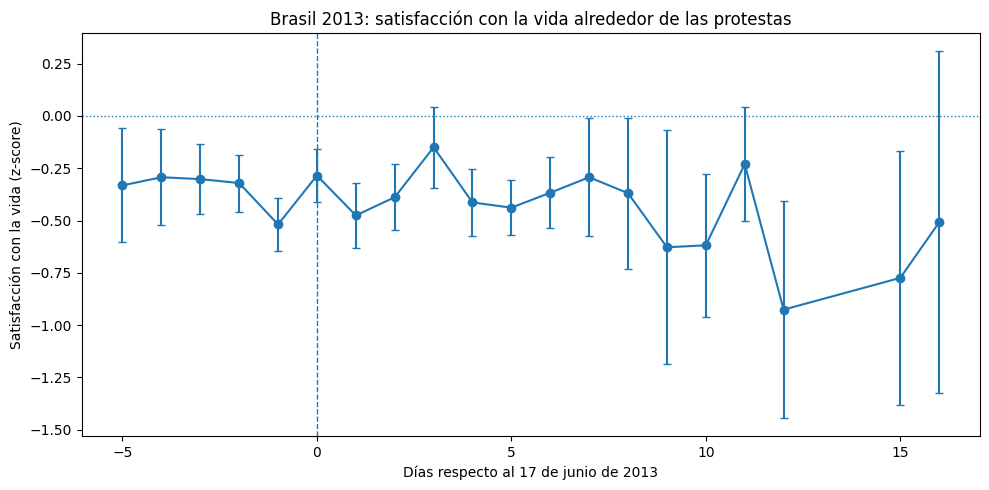

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ============================================================
# 1. Brasil 2013
# ============================================================

br = master[
    (master['country'] == 76) &
    (master['wave'] == 2013)
].copy()

# Fecha de entrevista
br['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=br['wave'],
        month=br['mes_real'],
        day=br['dia_real']
    ),
    errors='coerce'
)

# Eliminar fechas/outcome faltantes
br = br.dropna(
    subset=['fecha_entrevista', 'life_satisfaction_z']
).copy()


# ============================================================
# 2. Distancia respecto al evento
# ============================================================

fecha_evento = pd.Timestamp('2013-06-17')

br['dias_evento'] = (
    br['fecha_entrevista'] - fecha_evento
).dt.days

print(br[['fecha_entrevista', 'dias_evento']].head())

print("\nRango:")
print(br['dias_evento'].min(), br['dias_evento'].max())

print("\nN por día:")
print(
    br.groupby('dias_evento')
      .size()
      .sort_index()
)


# ============================================================
# 3. Promedio de felicidad por día
# ============================================================

daily = (
    br.groupby('dias_evento')
      .agg(
          felicidad=('life_satisfaction_z', 'mean'),
          sd=('life_satisfaction_z', 'std'),
          n=('life_satisfaction_z', 'size')
      )
      .reset_index()
)

daily['se'] = daily['sd'] / np.sqrt(daily['n'])

daily['ci_low'] = daily['felicidad'] - 1.96 * daily['se']
daily['ci_high'] = daily['felicidad'] + 1.96 * daily['se']


# ============================================================
# 4. Gráfico
# ============================================================

plt.figure(figsize=(10, 5))

plt.errorbar(
    daily['dias_evento'],
    daily['felicidad'],
    yerr=1.96 * daily['se'],
    fmt='o-',
    capsize=3
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=1
)

plt.axhline(
    0,
    linestyle=':',
    linewidth=1
)

plt.xlabel('Días respecto al 17 de junio de 2013')
plt.ylabel('Satisfacción con la vida (z-score)')
plt.title('Brasil 2013: satisfacción con la vida alrededor de las protestas')

plt.tight_layout()
plt.show()

In [51]:
# Crear períodos alrededor del 17 de junio
br['periodo_evento'] = pd.cut(
    br['dias_evento'],
    bins=[-6, -1, 3, 7, 20],
    labels=['Pre', 'Post_0_3', 'Post_4_7', 'Post_8_plus']
)

# Estadísticas
resumen = (
    br.groupby('periodo_evento', observed=True)
      .agg(
          felicidad=('life_satisfaction_z', 'mean'),
          sd=('life_satisfaction_z', 'std'),
          n=('life_satisfaction_z', 'size')
      )
      .reset_index()
)

resumen['se'] = resumen['sd'] / np.sqrt(resumen['n'])
resumen['ci_low'] = resumen['felicidad'] - 1.96 * resumen['se']
resumen['ci_high'] = resumen['felicidad'] + 1.96 * resumen['se']

print(resumen)

  periodo_evento  felicidad        sd    n        se    ci_low   ci_high
0            Pre  -0.389811  0.799720  436  0.038300 -0.464878 -0.314744
1       Post_0_3  -0.345109  0.760611  350  0.040656 -0.424796 -0.265423
2       Post_4_7  -0.405991  0.795704  346  0.042777 -0.489835 -0.322148
3    Post_8_plus  -0.585075  0.805922   71  0.095645 -0.772540 -0.397610


In [52]:
# Diferencia simple Post vs Pre
br['post'] = (br['dias_evento'] >= 0).astype(int)

modelo = smf.ols(
    'life_satisfaction_z ~ post',
    data=br
).fit(cov_type='HC1')

print(modelo.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.000
Model:                             OLS   Adj. R-squared:                 -0.001
Method:                  Least Squares   F-statistic:                   0.01093
Date:                 Wed, 09 Sep 2026   Prob (F-statistic):              0.917
Time:                         13:09:09   Log-Likelihood:                -1420.8
No. Observations:                 1203   AIC:                             2846.
Df Residuals:                     1201   BIC:                             2856.
Df Model:                            1                                         
Covariance Type:                   HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3898      0.038    -10.18

In [54]:
# Diferencia simple Post vs Pre
br['post'] = (br['dias_evento'] >= 0).astype(int)

modelo = smf.ols(
    'trust_people ~ post',
    data=br
).fit(cov_type='HC1')

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           trust_people   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.279
Date:                Wed, 09 Sep 2026   Prob (F-statistic):              0.258
Time:                        13:11:25   Log-Likelihood:                 148.38
No. Observations:                1172   AIC:                            -292.8
Df Residuals:                    1170   BIC:                            -282.6
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0386      0.009      4.076      0.0

In [55]:
# Diferencia simple Post vs Pre
br['post'] = (br['dias_evento'] >= 0).astype(int)

modelo = smf.ols(
    'confianza_institucional_z ~ post',
    data=br
).fit(cov_type='HC1')

print(modelo.summary())

                                OLS Regression Results                               
Dep. Variable:     confianza_institucional_z   R-squared:                       0.021
Model:                                   OLS   Adj. R-squared:                  0.020
Method:                        Least Squares   F-statistic:                     26.32
Date:                       Wed, 09 Sep 2026   Prob (F-statistic):           3.38e-07
Time:                               13:12:06   Log-Likelihood:                -1625.6
No. Observations:                       1183   AIC:                             3255.
Df Residuals:                           1181   BIC:                             3265.
Df Model:                                  1                                         
Covariance Type:                         HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Brasil 2013
es = master[
    (master['country'] == 76) &
    (master['wave'] == 2013)
].copy()

# Fecha
es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# Días respecto al 17 de junio
fecha_evento = pd.Timestamp('2013-06-17')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana
es = es[
    es['dias_evento'].between(-5, 16)
].dropna(
    subset=['confianza_institucional_z']
).copy()

# Convertimos día en variable categórica
es['dia_cat'] = es['dias_evento'].astype(int).astype(str)

# Event study
modelo_es = smf.ols(
    """
    confianza_institucional_z ~
    C(dia_cat, Treatment(reference='-1'))
    """,
    data=es
).fit(cov_type='HC1')

print(modelo_es.summary())

                                OLS Regression Results                               
Dep. Variable:     confianza_institucional_z   R-squared:                       0.062
Model:                                   OLS   Adj. R-squared:                  0.047
Method:                        Least Squares   F-statistic:                     4.708
Date:                       Wed, 09 Sep 2026   Prob (F-statistic):           1.21e-10
Time:                               13:13:26   Log-Likelihood:                -1601.0
No. Observations:                       1184   AIC:                             3242.
Df Residuals:                           1164   BIC:                             3344.
Df Model:                                 19                                         
Covariance Type:                         HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------

In [57]:
# Coeficientes del event study
coef = modelo_es.params
se = modelo_es.bse

resultados = []

for dia in range(-5, 17):
    if dia == -1:
        resultados.append({
            'dia': dia,
            'beta': 0,
            'se': 0
        })
    else:
        nombre = f"C(dia_cat, Treatment(reference='-1'))[T.{dia}]"

        if nombre in coef.index:
            resultados.append({
                'dia': dia,
                'beta': coef[nombre],
                'se': se[nombre]
            })

event = pd.DataFrame(resultados)

event['ci_low'] = event['beta'] - 1.96 * event['se']
event['ci_high'] = event['beta'] + 1.96 * event['se']

print(event)

    dia      beta        se    ci_low   ci_high
0    -5 -0.608579  0.196201 -0.993133 -0.224024
1    -4 -0.247894  0.175087 -0.591064  0.095276
2    -3 -0.253214  0.121996 -0.492325 -0.014102
3    -2 -0.167871  0.109205 -0.381913  0.046171
4    -1  0.000000  0.000000  0.000000  0.000000
5     0 -0.496302  0.121391 -0.734228 -0.258375
6     1 -0.554606  0.129187 -0.807812 -0.301400
7     2 -0.268806  0.131120 -0.525801 -0.011811
8     3 -0.568653  0.152282 -0.867126 -0.270180
9     4 -0.267244  0.122936 -0.508198 -0.026290
10    5 -0.303745  0.110178 -0.519693 -0.087797
11    6 -0.657708  0.129212 -0.910963 -0.404453
12    7 -0.897326  0.207204 -1.303445 -0.491207
13    8 -0.143985  0.266656 -0.666631  0.378662
14    9 -1.228037  0.213865 -1.647213 -0.808861
15   10 -0.525441  0.204988 -0.927217 -0.123664
16   11  0.079708  0.335077 -0.577043  0.736460
17   12 -0.345309  0.113256 -0.567290 -0.123328
18   15 -0.912676  0.225405 -1.354470 -0.470883
19   16 -0.949281  0.390568 -1.714793 -0

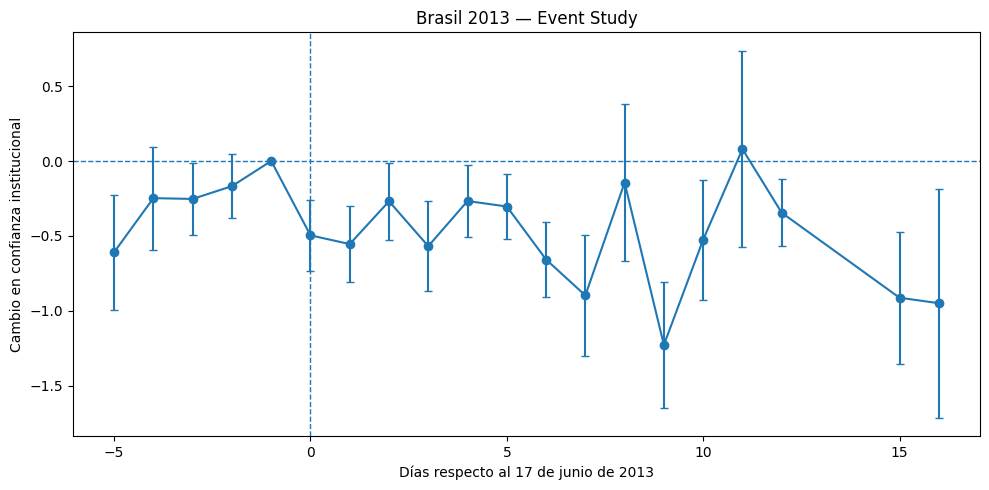

In [58]:
plt.figure(figsize=(10, 5))

plt.errorbar(
    event['dia'],
    event['beta'],
    yerr=1.96 * event['se'],
    fmt='o-',
    capsize=3
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.axvline(0, linestyle='--', linewidth=1)

plt.xlabel('Días respecto al 17 de junio de 2013')
plt.ylabel('Cambio en confianza institucional')
plt.title('Brasil 2013 — Event Study')

plt.tight_layout()
plt.show()

# Colombia 2018

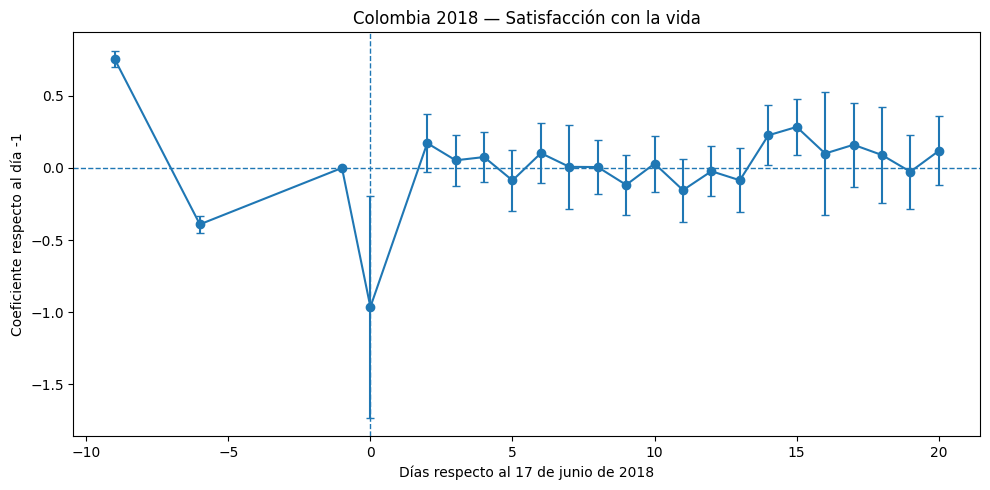

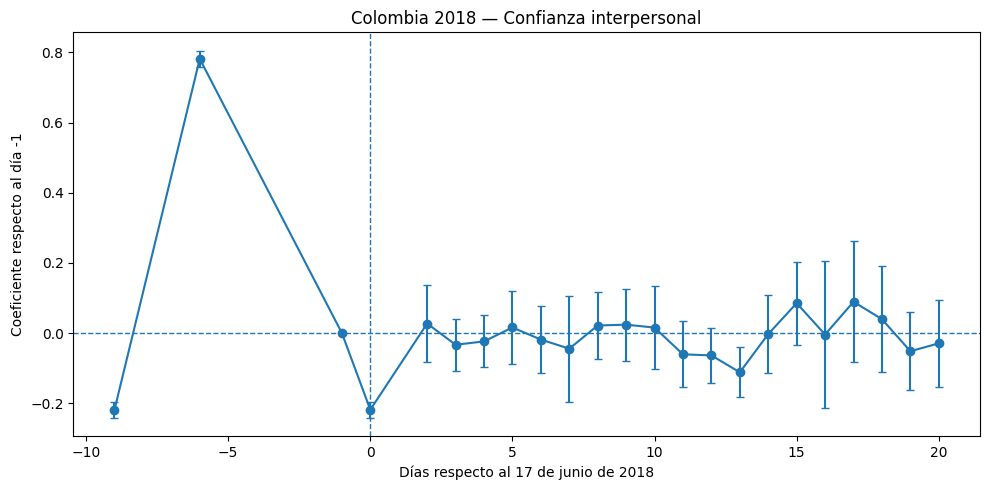

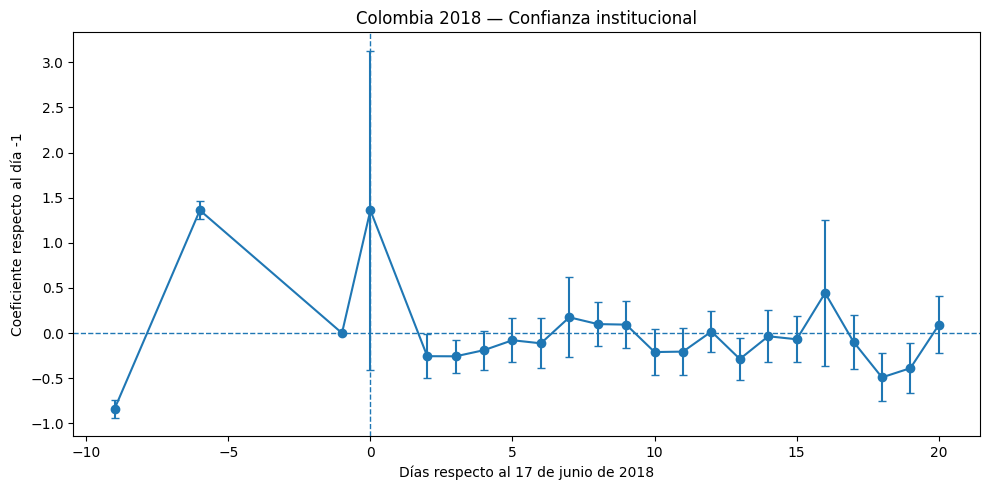

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


# ============================================================
# COLOMBIA 2018
# ============================================================

es = master[
    (master['country'] == 170) &
    (master['wave'] == 2018)
].copy()

es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# Segunda vuelta: 17 de junio de 2018
fecha_evento = pd.Timestamp('2018-06-17')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana
es = es[
    es['dias_evento'].between(-10, 20)
].copy()


# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(variable, titulo):

    data = es.dropna(subset=[variable]).copy()

    # Crear dummies
    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X.columns:
        X = X.drop(columns='dia_-1')

    # Constante
    X = sm.add_constant(X)

    # Estimación
    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    # Extraer resultados
    resultados = []

    for dia in range(-10, 21):

        if dia == -1:
            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al 17 de junio de 2018'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.title(titulo)

    plt.tight_layout()
    plt.show()

    return modelo, r


# ============================================================
# TRES EVENT STUDIES
# ============================================================

modelo_felicidad, resultados_felicidad = event_study(
    'life_satisfaction_z',
    'Colombia 2018 — Satisfacción con la vida'
)

modelo_interpersonal, resultados_interpersonal = event_study(
    'trust_people',
    'Colombia 2018 — Confianza interpersonal'
)

modelo_institucional, resultados_institucional = event_study(
    'confianza_institucional_z',
    'Colombia 2018 — Confianza institucional'
)

In [64]:
# ============================================================
# IMPRIMIR COEFICIENTES
# ============================================================

pd.set_option('display.max_rows', 100)

print("\n================ FELICIDAD ================\n")
print(resultados_felicidad[['dia', 'beta', 'se', 'ci_low', 'ci_high']].to_string(index=False))

print("\n================ CONFIANZA INTERPERSONAL ================\n")
print(resultados_interpersonal[['dia', 'beta', 'se', 'ci_low', 'ci_high']].to_string(index=False))

print("\n================ CONFIANZA INSTITUCIONAL ================\n")
print(resultados_institucional[['dia', 'beta', 'se', 'ci_low', 'ci_high']].to_string(index=False))


================ FELICIDAD ================

 dia      beta       se    ci_low   ci_high
  -9  0.754906 0.029561  0.696967  0.812845
  -6 -0.391097 0.029561 -0.449036 -0.333159
  -1  0.000000 0.000000  0.000000  0.000000
   0 -0.964099 0.392185 -1.732781 -0.195417
   2  0.171852 0.103717 -0.031433  0.375137
   3  0.052850 0.089763 -0.123086  0.228786
   4  0.075417 0.087767 -0.096606  0.247441
   5 -0.086690 0.108498 -0.299346  0.125965
   6  0.102566 0.106212 -0.105609  0.310741
   7  0.007513 0.148970 -0.284468  0.299493
   8  0.006184 0.094439 -0.178916  0.191284
   9 -0.117425 0.106205 -0.325587  0.090738
  10  0.029884 0.098662 -0.163493  0.223260
  11 -0.153993 0.111070 -0.371691  0.063704
  12 -0.022739 0.088687 -0.196566  0.151088
  13 -0.085496 0.112979 -0.306935  0.135942
  14  0.225981 0.106046  0.018130  0.433832
  15  0.284226 0.100315  0.087609  0.480843
  16  0.100047 0.217359 -0.325976  0.526070
  17  0.160682 0.149186 -0.131723  0.453088
  18  0.089485 0.168249 -0.240

# Perú 2016

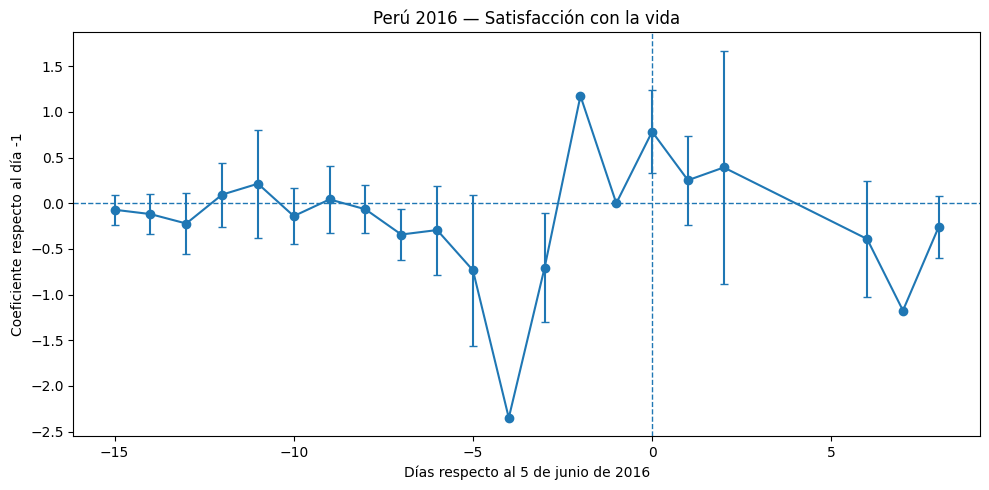

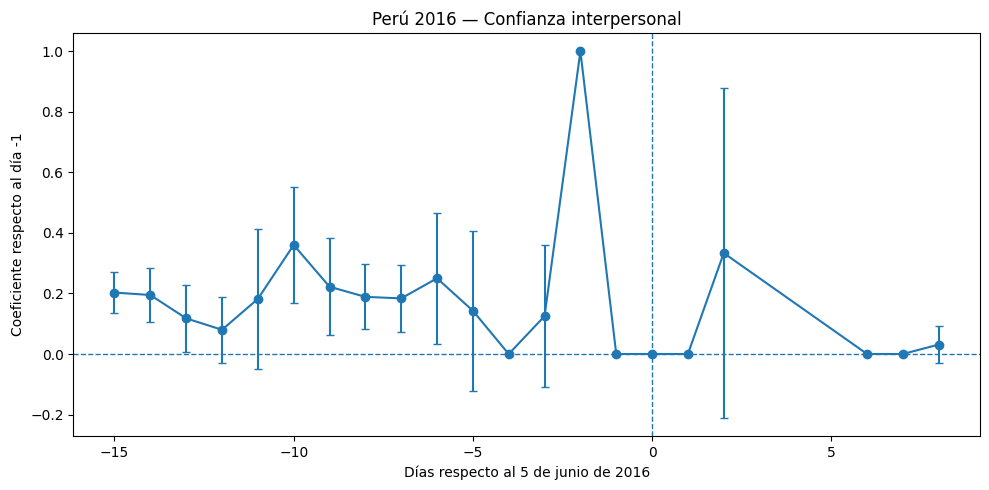

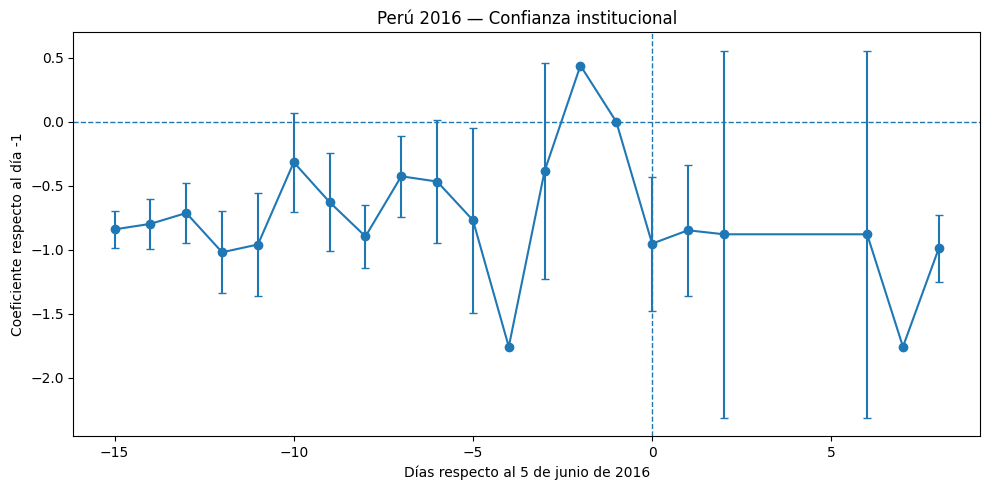


================ FELICIDAD ================

 dia      beta           se    ci_low   ci_high
 -15 -0.071454 8.352535e-02 -0.235164  0.092255
 -14 -0.118990 1.106086e-01 -0.335783  0.097803
 -13 -0.222303 1.703527e-01 -0.556194  0.111589
 -12  0.094002 1.782911e-01 -0.255448  0.443453
 -11  0.213641 3.009901e-01 -0.376299  0.803582
 -10 -0.141003 1.563265e-01 -0.447403  0.165397
  -9  0.041965 1.863425e-01 -0.323266  0.407197
  -8 -0.066511 1.334147e-01 -0.328004  0.194982
  -7 -0.342716 1.410163e-01 -0.619108 -0.066325
  -6 -0.293757 2.483579e-01 -0.780538  0.193025
  -5 -0.734392 4.202783e-01 -1.558138  0.089353
  -4 -2.350056 1.259329e-14 -2.350056 -2.350056
  -3 -0.705017 3.031040e-01 -1.299101 -0.110933
  -2  1.175028 1.282441e-14  1.175028  1.175028
  -1  0.000000 0.000000e+00  0.000000  0.000000
   0  0.783352 2.305790e-01  0.331417  1.235287
   1  0.251792 2.474016e-01 -0.233115  0.736699
   2  0.391676 6.521759e-01 -0.886589  1.669941
   6 -0.391676 3.260880e-01 -1.030808  0.2

In [65]:
# ============================================================
# PERÚ 2016
# ============================================================

es = master[
    (master['country'] == 604) &
    (master['wave'] == 2016)
].copy()

es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=es['wave'],
        month=es['mes_real'],
        day=es['dia_real']
    ),
    errors='coerce'
)

# Segunda vuelta presidencial: 5 de junio de 2016
fecha_evento = pd.Timestamp('2016-06-05')

es['dias_evento'] = (
    es['fecha_entrevista'] - fecha_evento
).dt.days

# Ventana: -15 a +8
es = es[
    es['dias_evento'].between(-15, 8)
].copy()


# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(variable, titulo):

    data = es.dropna(subset=[variable]).copy()

    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    if 'dia_-1' in X.columns:
        X = X.drop(columns='dia_-1')

    X = sm.add_constant(X)

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    resultados = []

    for dia in range(-15, 9):

        if dia == -1:
            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al 5 de junio de 2016'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.title(titulo)

    plt.tight_layout()
    plt.show()

    return modelo, r


# ============================================================
# TRES EVENT STUDIES
# ============================================================

modelo_felicidad, resultados_felicidad = event_study(
    'life_satisfaction_z',
    'Perú 2016 — Satisfacción con la vida'
)

modelo_interpersonal, resultados_interpersonal = event_study(
    'trust_people',
    'Perú 2016 — Confianza interpersonal'
)

modelo_institucional, resultados_institucional = event_study(
    'confianza_institucional_z',
    'Perú 2016 — Confianza institucional'
)


# ============================================================
# IMPRIMIR COEFICIENTES
# ============================================================

pd.set_option('display.max_rows', 100)

print("\n================ FELICIDAD ================\n")
print(resultados_felicidad[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INTERPERSONAL ================\n")
print(resultados_interpersonal[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))

print("\n================ CONFIANZA INSTITUCIONAL ================\n")
print(resultados_institucional[
    ['dia', 'beta', 'se', 'ci_low', 'ci_high']
].to_string(index=False))